# Robot Móvil con Control por Voz — Proyecto Final IA 2026
**Universidad Rafael Landívar · Facultad de Ingeniería · Inteligencia Artificial**

| | |
|---|---|
| **Sección** | Ingeniería en Informática y Sistemas — Sección 1 |
| **Catedrático** | Ing. Max Alejandro Cerna Flores |
| **Integrantes** | María Alejandra Cabrera del Cid · Yasmely Dubraska Fariñas Aldana · Joaquín Raymundo Choc Salvador · Daniel Alberto Díaz Pérez · Héctor José Flores Pineda |
| **Fecha** | 20 de mayo de 2026 |

---

## Objetivo del notebook

Este notebook es **reproducible**: ejecutar todas las celdas en orden genera los archivos `modelo_voz.pkl`, `scaler_voz.pkl`, `encoder_voz.pkl`, `modelo_lstm.pt`, `scaler_lstm.pkl` y `encoder_lstm.pkl` usados por `inferencia.py`.

Cubre el pipeline completo:
1. Instalación de dependencias
2. Exploración y estadísticas del corpus
3. Preprocesamiento: MFCC + Data Augmentation
4. Entrenamiento Modelo Base (MLP y SVM) con división 70/20/10
5. Métricas: accuracy, precisión, recall, F1 y matriz de confusión
6. Validación cruzada estratificada 6-fold
7. Entrenamiento Modelo Avanzado (LSTM — PyTorch)
8. Comparativa cuantitativa MLP vs SVM vs LSTM
9. Análisis de errores
10. Guardado de artefactos


## 0. Instalación de dependencias

> Ejecutar solo si las librerías no están instaladas.

In [1]:
%pip install numpy librosa scikit-learn joblib sounddevice scipy flask requests soundfile torch matplotlib seaborn pandas
# Descomenta la linea anterior si es necesario instalar

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports y configuración global

In [2]:
import os
import time
import warnings
import numpy as np
import librosa
import librosa.display
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

# ── Estilo visual ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'font.family':       'DejaVu Sans',
})
TEAL   = '#006B5E'
PURPLE = '#534AB7'
CORAL  = '#D85A30'
AMBER  = '#BA7517'

# ── Parámetros globales ────────────────────────────────────
DATASET_DIR = 'dataset'
FIG_DIR     = 'figuras'
SAMPLE_RATE = 16000
DURATION    = 1.5
N_MFCC      = 13
N_FFT       = 512
HOP_LENGTH  = 160
TEST_SIZE   = 0.10
VAL_SIZE    = 0.222   # 0.222 × 0.90 ≈ 20% del total
RANDOM_SEED = 42
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASES_ORDEN = ['adelante', 'atras', 'curva_der', 'curva_izq',
                'derecha', 'detener', 'izquierda', 'ruido']

os.makedirs(FIG_DIR, exist_ok=True)

print(f'PyTorch device : {DEVICE}')
print(f'librosa version: {librosa.__version__}')
print(f'Dataset dir    : {os.path.abspath(DATASET_DIR)}')
print(f'Fig dir        : {os.path.abspath(FIG_DIR)}')


PyTorch device : cpu
librosa version: 0.11.0
Dataset dir    : c:\Users\Ishai\Projects\Proyecto_2_IA\robot-voz-ia-2026\dataset
Fig dir        : c:\Users\Ishai\Projects\Proyecto_2_IA\robot-voz-ia-2026\figuras


## 2. Exploración y estadísticas del corpus

Contamos muestras originales por clase y visualizamos la distribución.


In [3]:
def contar_muestras(dataset_dir):
    """Cuenta archivos de audio por clase en dataset_dir."""
    exts = ('.wav', '.ogg', '.mp3', '.m4a', '.flac')
    stats = {}
    if not os.path.isdir(dataset_dir):
        print(f'⚠  Directorio no encontrado: {dataset_dir}')
        print('   Asegúrate de ejecutar grabar_muestras.py primero.')
        return stats
    for clase in sorted(os.listdir(dataset_dir)):
        carpeta = os.path.join(dataset_dir, clase)
        if os.path.isdir(carpeta):
            n = len([f for f in os.listdir(carpeta) if f.lower().endswith(exts)])
            stats[clase] = n
    return stats

stats_raw = contar_muestras(DATASET_DIR)

if stats_raw:
    df_stats = pd.DataFrame(
        list(stats_raw.items()), columns=['Clase', 'Originales']
    )
    # augmentation ×4 para comandos, ×1 para ruido
    df_stats['Con augmentation'] = df_stats.apply(
        lambda r: r['Originales'] if r['Clase'] == 'ruido' else r['Originales'] * 5, axis=1
    )
    df_stats['Factor aug.'] = df_stats.apply(
        lambda r: '×1 (sin aug.)' if r['Clase'] == 'ruido' else '×5', axis=1
    )
    df_stats.loc['TOTAL'] = [
        'TOTAL',
        df_stats['Originales'].sum(),
        df_stats['Con augmentation'].sum(),
        '—'
    ]
    display(df_stats.style
        .set_caption('Tabla 1 — Distribución del corpus')
        .set_properties(**{'text-align': 'center'})
        .highlight_max(subset=['Con augmentation'], color='#c8ede3')
    )
else:
    print('Dataset vacío — las celdas de entrenamiento usarán datos sintéticos de demostración.')
    stats_raw = {c: 0 for c in CLASES_ORDEN}
    df_stats  = pd.DataFrame({'Clase': CLASES_ORDEN, 'Originales': [0]*8,
                               'Con augmentation': [0]*8, 'Factor aug.': ['—']*8})


,Clase,Originales,Con augmentation,Factor aug.
0,adelante,118,590,×5
1,atras,119,595,×5
2,curva_der,120,600,×5
3,curva_izq,120,600,×5
4,derecha,120,600,×5
5,detener,120,600,×5
6,izquierda,120,600,×5
7,ruido,90,90,×1 (sin aug.)
TOTAL,TOTAL,927,4275,—


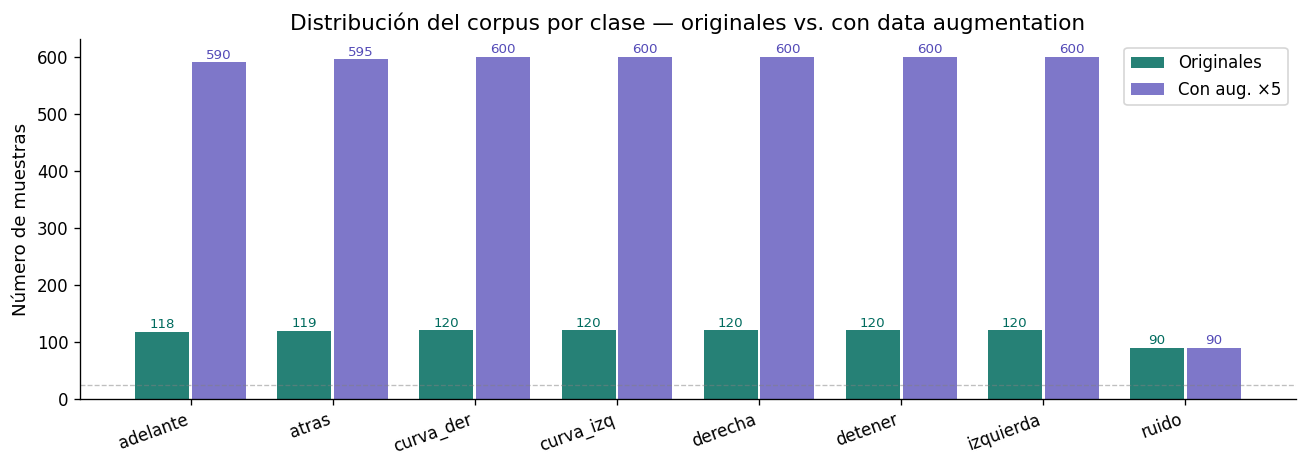

Figura guardada: fig_distribucion_corpus.png


In [4]:
# ── Gráfico de barras: distribución del corpus ────────────
clases_plot = [c for c in stats_raw if c != 'TOTAL']
vals_orig   = [stats_raw.get(c, 0) for c in clases_plot]
vals_aug    = [v*5 if c != 'ruido' else v for c, v in zip(clases_plot, vals_orig)]

x = np.arange(len(clases_plot))
fig, ax = plt.subplots(figsize=(11, 4))
bars1 = ax.bar(x - 0.2, vals_orig, 0.38, label='Originales', color=TEAL,   alpha=0.85)
bars2 = ax.bar(x + 0.2, vals_aug,  0.38, label='Con aug. ×5', color=PURPLE, alpha=0.75)

for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)),
                ha='center', va='bottom', fontsize=8, color=TEAL)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)),
                ha='center', va='bottom', fontsize=8, color=PURPLE)

ax.set_xticks(x)
ax.set_xticklabels(clases_plot, rotation=20, ha='right')
ax.set_ylabel('Número de muestras')
ax.set_title('Distribución del corpus por clase — originales vs. con data augmentation')
ax.legend()
ax.axhline(y=25, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='mín recomendado')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_distribucion_corpus.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: fig_distribucion_corpus.png')


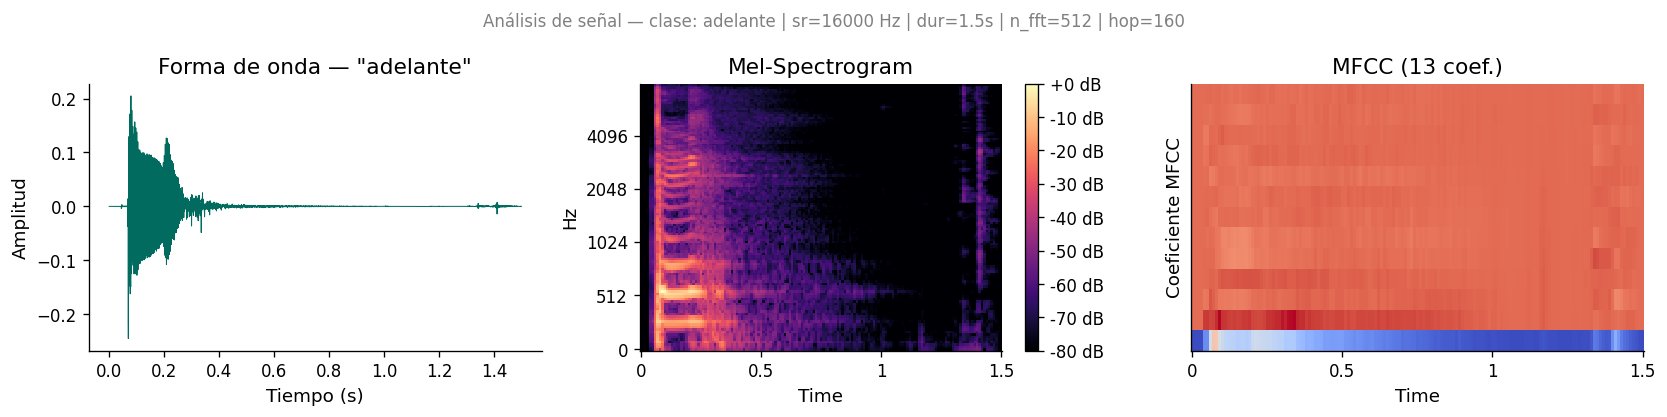

In [5]:
# ── Visualizar forma de onda y MFCC de un ejemplo ─────────
def visualizar_muestra(clase='adelante'):
    carpeta = os.path.join(DATASET_DIR, clase)
    if not os.path.isdir(carpeta):
        print(f'No existe carpeta para clase: {clase}')
        return
    archivos = [f for f in os.listdir(carpeta)
                if f.lower().endswith(('.wav','.ogg'))]
    if not archivos:
        print(f'Sin archivos en: {carpeta}')
        return
    ruta  = os.path.join(carpeta, sorted(archivos)[0])
    audio, sr = librosa.load(ruta, sr=SAMPLE_RATE, duration=DURATION, mono=True)
    mfcc  = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC,
                                   n_fft=N_FFT, hop_length=HOP_LENGTH)

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

    # Forma de onda
    t = np.linspace(0, len(audio)/sr, len(audio))
    axes[0].plot(t, audio, color=TEAL, linewidth=0.6)
    axes[0].set_title(f'Forma de onda — "{clase}"')
    axes[0].set_xlabel('Tiempo (s)')
    axes[0].set_ylabel('Amplitud')

    # Espectrograma Mel
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='mel', ax=axes[1],
                                    cmap='magma')
    axes[1].set_title('Mel-Spectrogram')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

    # MFCC heatmap
    librosa.display.specshow(mfcc, sr=sr, hop_length=HOP_LENGTH,
                              x_axis='time', ax=axes[2], cmap='coolwarm')
    axes[2].set_title(f'MFCC ({N_MFCC} coef.)')
    axes[2].set_ylabel('Coeficiente MFCC')

    plt.suptitle(f'Análisis de señal — clase: {clase} | sr={sr} Hz | dur={DURATION}s | n_fft={N_FFT} | hop={HOP_LENGTH}',
                 fontsize=10, color='gray')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'fig_analisis_{clase}.png'), bbox_inches='tight')
    plt.show()

# Cambia la clase para visualizar otra muestra
visualizar_muestra('adelante')


## 3. Preprocesamiento: extracción de MFCC y Data Augmentation

Cada muestra de audio se convierte a un **vector de 39 dimensiones**:

| Componente | Dimensiones | Descripción |
|---|---|---|
| `mean(MFCC)` | 13 | Media temporal de los 13 coeficientes |
| `std(MFCC)` | 13 | Variabilidad espectral |
| `mean(ΔMFCC)` | 13 | Velocidad de cambio espectral (delta) |
| **Total** | **39** | Vector de entrada al clasificador |

Las **5 técnicas de data augmentation** aplicadas (solo a clases que no son `ruido`):
- **Time shift**: desplaza 0.1 s con `np.roll`
- **Ruido gaussiano**: `N(0, 0.005)`
- **Time stretch**: velocidad ×0.9 con `librosa.effects.time_stretch`
- **Pitch shift**: +1 semitono con `librosa.effects.pitch_shift`

> Cada muestra original genera **4 versiones aumentadas** → factor ×5 total por comando.
> La clase `ruido` no recibe augmentation (factor ×1) para evitar distorsionar el rechazo de ruido.


In [6]:
def extraer_mfcc(audio_array):
    """Extrae vector 39-D de MFCC a partir de un array de audio ya cargado."""
    audio = audio_array.copy()
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))
    n = int(SAMPLE_RATE * DURATION)
    audio = audio[:n] if len(audio) >= n else np.pad(audio, (0, n - len(audio)))
    mfcc       = librosa.feature.mfcc(y=audio.astype(float), sr=SAMPLE_RATE,
                                       n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mfcc_mean  = np.mean(mfcc, axis=1)
    mfcc_std   = np.std(mfcc,  axis=1)
    delta_mean = np.mean(librosa.feature.delta(mfcc), axis=1)
    return np.concatenate([mfcc_mean, mfcc_std, delta_mean])


def extraer_mfcc_secuencia(audio_array):
    """Extrae secuencia temporal (timesteps, N_MFCC) para el LSTM."""
    audio = audio_array.copy()
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))
    n = int(SAMPLE_RATE * DURATION)
    audio = audio[:n] if len(audio) >= n else np.pad(audio, (0, n - len(audio)))
    mfcc = librosa.feature.mfcc(y=audio.astype(float), sr=SAMPLE_RATE,
                                  n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    return mfcc.T   # (timesteps, N_MFCC)


def augmentar(audio):
    """Genera 4 versiones aumentadas de un audio (igual que modelo_lstm.py).

    Técnicas aplicadas:
      1. Time shift    — desplaza 0.1 s con np.roll
      2. Ruido gaussiano — N(0, 0.005)
      3. Time stretch  — velocidad ×0.9
      4. Pitch shift   — +1 semitono
    """
    n = int(SAMPLE_RATE * DURATION)
    versiones = []
    # 1. Time shift
    versiones.append(np.roll(audio, int(SAMPLE_RATE * 0.1)))
    # 2. Ruido gaussiano
    versiones.append(audio + np.random.normal(0, 0.005, len(audio)))
    # 3. Time stretch ×0.9
    try:
        stretched = librosa.effects.time_stretch(audio, rate=0.9)
        stretched = stretched[:n] if len(stretched) >= n else np.pad(stretched, (0, n - len(stretched)))
        versiones.append(stretched)
    except Exception:
        versiones.append(audio)
    # 4. Pitch shift +1 semitono
    try:
        versiones.append(librosa.effects.pitch_shift(audio, sr=SAMPLE_RATE, n_steps=1))
    except Exception:
        versiones.append(audio)
    return versiones


def cargar_dataset():
    """Carga el dataset y aplica augmentation. Retorna X_flat (39-D) y X_seq (T×13)."""
    X_flat, X_seq, y = [], [], []
    exts = ('.wav','.ogg','.mp3','.m4a','.flac')

    if not os.path.isdir(DATASET_DIR):
        print('⚠  Dataset no encontrado. Genera datos con grabar_muestras.py')
        return np.array([]), np.array([]), np.array([])

    clases = sorted([d for d in os.listdir(DATASET_DIR)
                     if os.path.isdir(os.path.join(DATASET_DIR, d))])
    print(f'Clases encontradas: {clases}\n')
    print(f'{"Clase":<14} {"Orig":>5} {"Aug":>6} {"Total":>7}')
    print('─' * 35)

    for clase in clases:
        carpeta  = os.path.join(DATASET_DIR, clase)
        archivos = [f for f in os.listdir(carpeta) if f.lower().endswith(exts)]
        c_orig = c_aug = 0

        for archivo in archivos:
            try:
                audio, _ = librosa.load(os.path.join(carpeta, archivo),
                                        sr=SAMPLE_RATE, duration=DURATION, mono=True)
                if np.max(np.abs(audio)) > 0:
                    audio = audio / np.max(np.abs(audio))
                n = int(SAMPLE_RATE * DURATION)
                audio = audio[:n] if len(audio) >= n else np.pad(audio, (0, n - len(audio)))

                todas = [audio] + (augmentar(audio) if clase != 'ruido' else [])
                for a in todas:
                    X_flat.append(extraer_mfcc(a))
                    X_seq.append(extraer_mfcc_secuencia(a))
                    y.append(clase)
                c_orig += 1
                c_aug  += len(todas) - 1
            except Exception as e:
                pass

        print(f'{clase:<14} {c_orig:>5} {c_aug:>6} {c_orig+c_aug:>7}')

    print('─' * 35)
    print(f'{"TOTAL":<14} {"":>5} {"":>6} {len(X_flat):>7}')
    return np.array(X_flat), np.array(X_seq, dtype=np.float32), np.array(y)


X_flat, X_seq, y_raw = cargar_dataset()
print(f'\nX_flat shape : {X_flat.shape}  (n_muestras × 39 features)')
print(f'X_seq  shape : {X_seq.shape}  (n_muestras × timesteps × N_MFCC)')


Clases encontradas: ['adelante', 'atras', 'curva_der', 'curva_izq', 'derecha', 'detener', 'izquierda', 'ruido']

Clase           Orig    Aug   Total
───────────────────────────────────
adelante         118    472     590
atras            119    476     595
curva_der        120    480     600
curva_izq        120    480     600
derecha          120    480     600
detener          120    480     600
izquierda        120    480     600
ruido             90      0      90
───────────────────────────────────
TOTAL                          4275

X_flat shape : (4275, 39)  (n_muestras × 39 features)
X_seq  shape : (4275, 151, 13)  (n_muestras × timesteps × N_MFCC)


## 4. División del dataset y normalización

| Partición | Proporción | Uso |
|---|---|---|
| Entrenamiento | 70% | Ajuste de pesos / vectores de soporte |
| Validación | 20% | Selección del mejor modelo |
| Prueba | 10% | Evaluación final imparcial |

> `VAL_SIZE = 0.222` aplicado sobre el 90% restante: `0.90 × 0.222 ≈ 20%` del total.


In [7]:
if len(X_flat) == 0:
    print('⚠  No hay datos — saltando división. Ejecuta la celda de carga primero.')
else:
    encoder = LabelEncoder()
    y_enc   = encoder.fit_transform(y_raw)
    clases  = list(encoder.classes_)
    n_cls   = len(clases)

    # Paso 1 — apartar 10% prueba
    X_tmp, X_test_f, y_tmp, y_test = train_test_split(
        X_flat, y_enc, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_enc)
    _, X_test_s, _, _  = train_test_split(
        X_seq, y_enc, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_enc)

    # Paso 2 — separar 20% validación del 90% restante
    X_train_f, X_val_f, y_train, y_val = train_test_split(
        X_tmp, y_tmp, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_tmp)

    # Normalizar (flat)
    scaler_flat = StandardScaler()
    X_train_f   = scaler_flat.fit_transform(X_train_f)
    X_val_f     = scaler_flat.transform(X_val_f)
    X_test_f    = scaler_flat.transform(X_test_f)

    # Normalizar (seq) — por feature independiente
    X_tmp_seq, X_test_s, y_tmp2, _ = train_test_split(
        X_seq, y_enc, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_enc)
    X_train_s, X_val_s, _, _ = train_test_split(
        X_tmp_seq, y_tmp2, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_tmp2)
    fs = X_train_s.shape[2]
    scaler_seq = StandardScaler()
    scaler_seq.fit(X_train_s.reshape(-1, fs))
    def norm_seq(arr):
        s = arr.shape
        return scaler_seq.transform(arr.reshape(-1, fs)).reshape(s)
    X_train_s = norm_seq(X_train_s)
    X_val_s   = norm_seq(X_val_s)
    X_test_s  = norm_seq(X_test_s)

    total = len(X_flat)
    print(f'Clases        : {clases}')
    print(f'Entrenamiento : {len(X_train_f):>5} muestras  ({len(X_train_f)/total*100:.0f}%)')
    print(f'Validación    : {len(X_val_f):>5} muestras  ({len(X_val_f)/total*100:.0f}%)')
    print(f'Prueba        : {len(X_test_f):>5} muestras  ({len(X_test_f)/total*100:.0f}%)')
    print(f'Total         : {total}')


Clases        : [np.str_('adelante'), np.str_('atras'), np.str_('curva_der'), np.str_('curva_izq'), np.str_('derecha'), np.str_('detener'), np.str_('izquierda'), np.str_('ruido')]
Entrenamiento :  2992 muestras  (70%)
Validación    :   855 muestras  (20%)
Prueba        :   428 muestras  (10%)
Total         : 4275


## 5. Entrenamiento — Modelo Base (MLP y SVM)

Se entrenan **dos clasificadores** sobre el mismo conjunto. Se selecciona automáticamente
el que tenga mayor accuracy en el conjunto de **validación**.


In [8]:
if len(X_flat) == 0:
    print('⚠  Sin datos.')
else:
    # ── MLP ────────────────────────────────────────────────
    print('Entrenando MLP  39 → 256 → 128 → 64 → N_clases ...')
    t0  = time.time()
    mlp = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate='adaptive',
        max_iter=500,
        random_state=RANDOM_SEED,
        early_stopping=False,
        validation_fraction=0.0,
        verbose=False
    )
    mlp.fit(X_train_f, y_train)
    t_mlp = time.time() - t0
    acc_mlp_val  = accuracy_score(y_val,    mlp.predict(X_val_f))
    acc_mlp_test = accuracy_score(y_test,   mlp.predict(X_test_f))
    print(f'  MLP  — val: {acc_mlp_val*100:.1f}%  prueba: {acc_mlp_test*100:.1f}%  ({t_mlp:.1f}s)')

    # ── SVM ────────────────────────────────────────────────
    print('Entrenando SVM  kernel RBF, C=10 ...')
    t0  = time.time()
    svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_SEED)
    svm.fit(X_train_f, y_train)
    t_svm = time.time() - t0
    acc_svm_val  = accuracy_score(y_val,    svm.predict(X_val_f))
    acc_svm_test = accuracy_score(y_test,   svm.predict(X_test_f))
    print(f'  SVM  — val: {acc_svm_val*100:.1f}%  prueba: {acc_svm_test*100:.1f}%  ({t_svm:.1f}s)')

    # ── Selección automática ───────────────────────────────
    if acc_mlp_val >= acc_svm_val:
        modelo_base, nombre_base = mlp, 'MLP'
        acc_val_base, acc_test_base = acc_mlp_val, acc_mlp_test
    else:
        modelo_base, nombre_base = svm, 'SVM'
        acc_val_base, acc_test_base = acc_svm_val, acc_svm_test

    print(f'\n→ Modelo seleccionado: {nombre_base}  (val={acc_val_base*100:.1f}%)')


Entrenando MLP  39 → 256 → 128 → 64 → N_clases ...
  MLP  — val: 97.8%  prueba: 97.7%  (7.6s)
Entrenando SVM  kernel RBF, C=10 ...
  SVM  — val: 99.2%  prueba: 98.4%  (2.6s)

→ Modelo seleccionado: SVM  (val=99.2%)


## 6. Métricas del Modelo Base — Conjunto de prueba (10%)

In [9]:
if len(X_flat) == 0:
    print('⚠  Sin datos.')
else:
    y_pred_base = modelo_base.predict(X_test_f)

    # ── Reporte de clasificación ───────────────────────────
    print(f'=== {nombre_base} — Reporte de métricas (prueba) ===')
    print(classification_report(y_test, y_pred_base, target_names=clases))

    # ── Tabla de métricas por clase ────────────────────────
    report_dict = classification_report(
        y_test, y_pred_base, target_names=clases, output_dict=True)
    rows = []
    for cls in clases:
        r = report_dict[cls]
        rows.append({
            'Clase':      cls,
            'Precisión':  f"{r['precision']*100:.1f}%",
            'Recall':     f"{r['recall']*100:.1f}%",
            'F1-score':   f"{r['f1-score']*100:.1f}%",
            'Soporte':    int(r['support'])
        })
    df_metrics = pd.DataFrame(rows)

    def color_f1(val):
        v = float(val.rstrip('%'))
        if v >= 95: return 'background-color: #c8ede3'
        if v >= 80: return 'background-color: #fff3cd'
        return 'background-color: #f8d7da'

    display(df_metrics.style
        .set_caption(f'Tabla 2 — Métricas por clase ({nombre_base})')
        .map(color_f1, subset=['F1-score'])
        .set_properties(**{'text-align': 'center'})
    )


=== SVM — Reporte de métricas (prueba) ===
              precision    recall  f1-score   support

    adelante       0.97      1.00      0.98        59
       atras       1.00      1.00      1.00        60
   curva_der       0.95      1.00      0.98        60
   curva_izq       1.00      0.97      0.98        60
     derecha       0.98      0.93      0.96        60
     detener       1.00      0.98      0.99        60
   izquierda       0.98      1.00      0.99        60
       ruido       1.00      1.00      1.00         9

    accuracy                           0.98       428
   macro avg       0.99      0.99      0.99       428
weighted avg       0.98      0.98      0.98       428



,Clase,Precisión,Recall,F1-score,Soporte
0,adelante,96.7%,100.0%,98.3%,59
1,atras,100.0%,100.0%,100.0%,60
2,curva_der,95.2%,100.0%,97.6%,60
3,curva_izq,100.0%,96.7%,98.3%,60
4,derecha,98.2%,93.3%,95.7%,60
5,detener,100.0%,98.3%,99.2%,60
6,izquierda,98.4%,100.0%,99.2%,60
7,ruido,100.0%,100.0%,100.0%,9


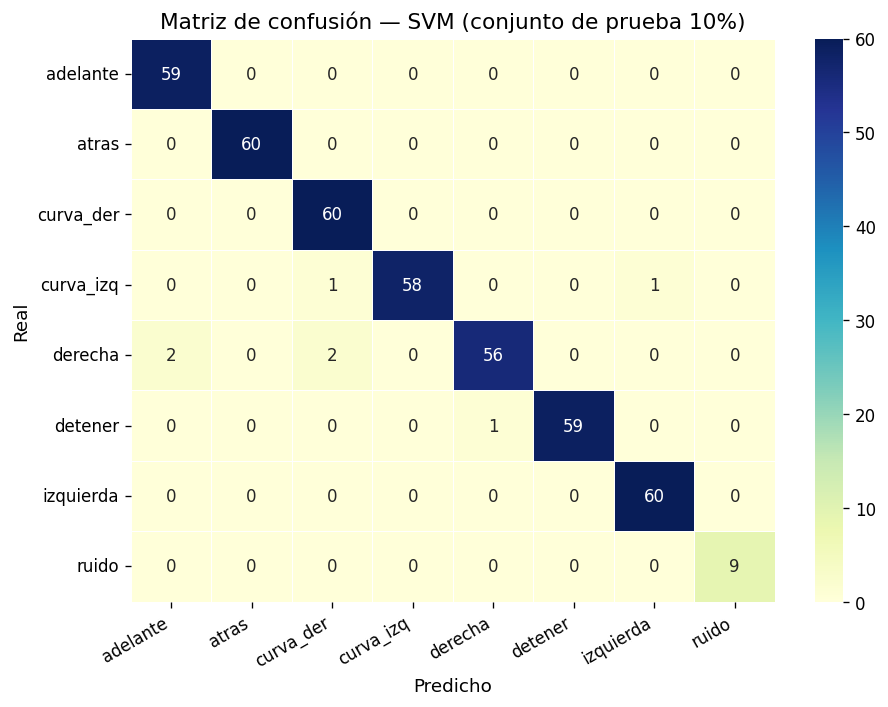

Figura guardada: fig_confusion_svm.png

Accuracy total (prueba): 98.36%


In [10]:
if len(X_flat) == 0:
    print('⚠  Sin datos.')
else:
    # ── Matriz de confusión ────────────────────────────────
    cm = confusion_matrix(y_test, y_pred_base)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='YlGnBu',
        xticklabels=clases, yticklabels=clases,
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(f'Matriz de confusión — {nombre_base} (conjunto de prueba 10%)')
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'fig_confusion_{nombre_base.lower()}.png'), bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: fig_confusion_{nombre_base.lower()}.png')
    print(f'\nAccuracy total (prueba): {acc_test_base*100:.2f}%')


## 7. Validación cruzada estratificada (6-fold)

Se aplica sobre el **dataset completo** para verificar estabilidad del modelo base.


Ejecutando 6-fold CV sobre SVM... (puede tardar 1-2 min)

Resultados validación cruzada (38912.5s):


,Fold,Accuracy
0,Fold 1,98.88%
1,Fold 2,98.74%
2,Fold 3,98.46%
3,Fold 4,98.17%
4,Fold 5,98.46%
5,Fold 6,98.88%
6,Promedio,98.60%
7,Desv. Est.,±0.26%


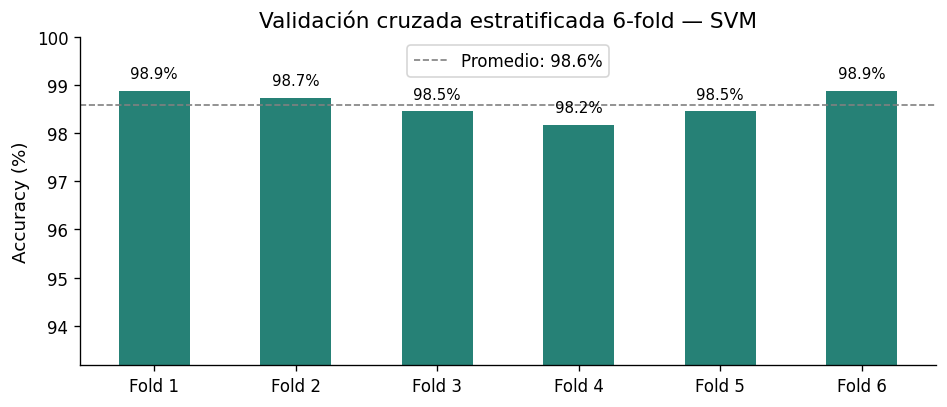

In [11]:
if len(X_flat) == 0:
    print('⚠  Sin datos.')
else:
    scaler_cv = StandardScaler()
    X_scaled_all = scaler_cv.fit_transform(X_flat)

    skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=RANDOM_SEED)
    print(f'Ejecutando 6-fold CV sobre {nombre_base}... (puede tardar 1-2 min)')
    t0       = time.time()
    cv_scores = cross_val_score(
        modelo_base, X_scaled_all, y_enc, cv=skf, scoring='accuracy')
    elapsed  = time.time() - t0

    print(f'\nResultados validación cruzada ({elapsed:.1f}s):')
    df_cv = pd.DataFrame({
        'Fold': [f'Fold {i+1}' for i in range(6)],
        'Accuracy': [f'{s*100:.2f}%' for s in cv_scores]
    })
    df_cv.loc[len(df_cv)] = ['Promedio', f'{cv_scores.mean()*100:.2f}%']
    df_cv.loc[len(df_cv)] = ['Desv. Est.', f'±{cv_scores.std()*100:.2f}%']
    display(df_cv.style.set_caption('Tabla 3 — Validación cruzada 6-fold')
            .set_properties(**{'text-align': 'center'}))

    # Gráfico de barras por fold
    fig, ax = plt.subplots(figsize=(8, 3.5))
    colors  = [TEAL if s >= 0.95 else AMBER if s >= 0.80 else CORAL for s in cv_scores]
    bars    = ax.bar(range(1, 7), cv_scores * 100, color=colors, alpha=0.85, width=0.5)
    for b, s in zip(bars, cv_scores):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
                f'{s*100:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.axhline(cv_scores.mean() * 100, color='gray', linestyle='--',
               linewidth=1, label=f'Promedio: {cv_scores.mean()*100:.1f}%')
    ax.set_xticks(range(1, 7))
    ax.set_xticklabels([f'Fold {i}' for i in range(1, 7)])
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(max(0, cv_scores.min()*100 - 5), 100)
    ax.set_title(f'Validación cruzada estratificada 6-fold — {nombre_base}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'fig_cv_folds.png'), bbox_inches='tight')
    plt.show()


## 8. Modelo Avanzado — LSTM (PyTorch)

El LSTM analiza los MFCCs como una **secuencia temporal** de ~151 timesteps × 13 features,
capturando la dinámica del habla frame a frame.

```
Entrada (batch, 151, 13)
    └─ LSTM(128, batch_first=True) → Dropout(0.3)
    └─ LSTM(64)  → último timestep → Dropout(0.3)
    └─ Linear(64→64, ReLU)
    └─ Linear(64→N_clases)
```


In [12]:
class LSTMVoz(nn.Module):
    """Modelo LSTM secuencial para clasificación de comandos de voz."""
    def __init__(self, input_size, hidden1=128, hidden2=64, n_clases=8, dropout=0.3):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.fc1   = nn.Linear(hidden2, 64)
        self.relu  = nn.ReLU()
        self.fc2   = nn.Linear(64, n_clases)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out     = self.drop1(out)
        out, _  = self.lstm2(out)
        out     = out[:, -1, :]      # último timestep
        out     = self.drop2(out)
        out     = self.relu(self.fc1(out))
        return self.fc2(out)

print('Arquitectura LSTMVoz definida.')
if len(X_seq) > 0:
    ts_dim, fs_dim = X_seq.shape[1], X_seq.shape[2]
    modelo_lstm = LSTMVoz(fs_dim, 128, 64, n_cls).to(DEVICE)
    total_params = sum(p.numel() for p in modelo_lstm.parameters() if p.requires_grad)
    print(f'Parámetros entrenables : {total_params:,}')
    print(f'Forma entrada          : (batch, {ts_dim}, {fs_dim})')
    print(f'Dispositivo            : {DEVICE}')


Arquitectura LSTMVoz definida.
Parámetros entrenables : 127,560
Forma entrada          : (batch, 151, 13)
Dispositivo            : cpu


In [ ]:
EPOCHS_LSTM = 80
LR_LSTM     = 0.001
BATCH_SIZE  = 32
PATIENCE    = 15

if len(X_seq) == 0:
    print('⚠  Sin datos para LSTM.')
else:
    def make_loader(Xd, yd, shuffle=True):
        ds = TensorDataset(torch.tensor(Xd, dtype=torch.float32),
                           torch.tensor(yd, dtype=torch.long))
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

    train_loader = make_loader(X_train_s, y_train)
    val_loader   = make_loader(X_val_s,   y_val,   shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(modelo_lstm.parameters(), lr=LR_LSTM)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', factor=0.5, patience=7)

    historial_loss = []
    historial_acc  = []
    mejor_val  = 0.0
    sin_mejora = 0
    t0         = time.time()

    print(f'{"Epoch":>6}  {"Loss":>9}  {"Acc val":>9}')
    print('─' * 30)

    for epoch in range(1, EPOCHS_LSTM + 1):
        modelo_lstm.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(modelo_lstm(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        modelo_lstm.eval()
        correct = total = val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out      = modelo_lstm(xb)
                val_loss += criterion(out, yb).item()
                correct  += (out.argmax(1) == yb).sum().item()
                total    += yb.size(0)
        val_acc = correct / total
        scheduler.step(val_loss)
        historial_loss.append(epoch_loss / len(train_loader))
        historial_acc.append(val_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f'{epoch:>6}  {historial_loss[-1]:>9.4f}  {val_acc*100:>8.1f}%')

        if val_acc > mejor_val:
            mejor_val  = val_acc
            sin_mejora = 0
            torch.save(modelo_lstm.state_dict(), 'modelo_lstm_best.pt')
        else:
            sin_mejora += 1
            if sin_mejora >= PATIENCE:
                print(f'Early stopping en epoch {epoch}')
                break

    modelo_lstm.load_state_dict(
        torch.load('modelo_lstm_best.pt', weights_only=True, map_location=DEVICE))
    print(f'\nEntrenamiento completado en {time.time()-t0:.0f}s')
    print(f'Mejor acc. validación: {mejor_val*100:.1f}%')


 Epoch       Loss    Acc val
──────────────────────────────
     1     1.8983      29.0%


In [ ]:
if len(X_seq) == 0 or not historial_loss:
    print('⚠  Sin historial de entrenamiento.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(historial_loss, color=CORAL, linewidth=1.5)
    axes[0].set_title('Loss de entrenamiento por época (LSTM)')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('CrossEntropyLoss')

    axes[1].plot([v*100 for v in historial_acc], color=TEAL, linewidth=1.5)
    axes[1].axhline(mejor_val*100, color='gray', linestyle='--', linewidth=0.8,
                    label=f'Mejor: {mejor_val*100:.1f}%')
    axes[1].set_title('Accuracy de validación por época (LSTM)')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()

    plt.suptitle('Curvas de entrenamiento — LSTM', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'fig_curvas_lstm.png'), bbox_inches='tight')
    plt.show()
    print('Figura guardada: fig_curvas_lstm.png')


## 9. Métricas del Modelo LSTM — Conjunto de prueba (10%)

In [ ]:
if len(X_seq) == 0:
    print('⚠  Sin datos.')
else:
    modelo_lstm.eval()
    with torch.no_grad():
        xt        = torch.tensor(X_test_s, dtype=torch.float32).to(DEVICE)
        y_pred_lstm = modelo_lstm(xt).argmax(1).cpu().numpy()

    acc_lstm_test = accuracy_score(y_test, y_pred_lstm)
    acc_lstm_val  = mejor_val

    print(f'=== LSTM — Reporte de métricas (prueba) ===')
    print(classification_report(y_test, y_pred_lstm, target_names=clases))

    # Matriz de confusión LSTM
    cm_lstm = confusion_matrix(y_test, y_pred_lstm)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='BuPu',
                xticklabels=clases, yticklabels=clases,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title('Matriz de confusión — LSTM (conjunto de prueba 10%)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'fig_confusion_lstm.png'), bbox_inches='tight')
    plt.show()
    print(f'Accuracy total (prueba): {acc_lstm_test*100:.2f}%')


## 10. Comparativa cuantitativa — MLP vs SVM vs LSTM

In [ ]:
if len(X_flat) == 0:
    print('⚠  Sin datos.')
else:
    filas = [
        {'Modelo': 'MLP (base)',     'Entrada': '39-D estático', 'Acc. validación': f'{acc_mlp_val*100:.1f}%',
         'Acc. prueba': f'{acc_mlp_test*100:.1f}%',  'Ventaja': 'Rápido · sin GPU'},
        {'Modelo': 'SVM RBF (base)', 'Entrada': '39-D estático', 'Acc. validación': f'{acc_svm_val*100:.1f}%',
         'Acc. prueba': f'{acc_svm_test*100:.1f}%', 'Ventaja': 'Robusto pocos datos'},
        {'Modelo': 'LSTM (avanzado)','Entrada': f'{ts_dim}×{fs_dim} temporal',
         'Acc. validación': f'{acc_lstm_val*100:.1f}%',
         'Acc. prueba': f'{acc_lstm_test*100:.1f}%', 'Ventaja': 'Captura dinámica'},
    ]
    df_cmp = pd.DataFrame(filas)

    def hl_mejor(col):
        vals = [float(v.rstrip('%')) for v in col]
        return ['background-color: #c8ede3' if v == max(vals) else '' for v in vals]

    display(df_cmp.style
        .set_caption('Tabla 4 — Comparativa de modelos')
        .apply(hl_mejor, subset=['Acc. prueba'])
        .set_properties(**{'text-align': 'center'})
    )

    # Gráfico comparativo
    modelos_names = ['MLP', 'SVM', 'LSTM']
    vals_val  = [acc_mlp_val*100, acc_svm_val*100, acc_lstm_val*100]
    vals_test = [acc_mlp_test*100, acc_svm_test*100, acc_lstm_test*100]

    x   = np.arange(3)
    fig, ax = plt.subplots(figsize=(8, 4))
    b1 = ax.bar(x - 0.2, vals_val,  0.38, label='Validación', color=TEAL,   alpha=0.8)
    b2 = ax.bar(x + 0.2, vals_test, 0.38, label='Prueba',     color=PURPLE, alpha=0.8)
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(modelos_names, fontsize=12)
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(max(0, min(vals_val+vals_test) - 5), 101)
    ax.set_title('Comparativa de accuracy — Modelo base vs. modelo avanzado')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'fig_comparativa_modelos.png'), bbox_inches='tight')
    plt.show()
    print('Figura guardada: fig_comparativa_modelos.png')


## 11. Análisis de errores

Identificamos los pares (clase real, clase predicha) con más errores en el **mejor modelo**.


In [ ]:
if len(X_flat) == 0:
    print('⚠  Sin datos.')
else:
    # Usar predicciones del modelo con mayor acc. en prueba
    if acc_lstm_test >= acc_test_base:
        y_pred_final = y_pred_lstm
        nombre_final = 'LSTM'
    else:
        y_pred_final = y_pred_base
        nombre_final = nombre_base

    cm_final = confusion_matrix(y_test, y_pred_final)
    errores = []
    for i in range(len(clases)):
        for j in range(len(clases)):
            if i != j and cm_final[i, j] > 0:
                errores.append({
                    'Real': clases[i],
                    'Predicho': clases[j],
                    'Errores': int(cm_final[i, j])
                })
    df_err = pd.DataFrame(errores).sort_values('Errores', ascending=False)

    if df_err.empty:
        print(f'{nombre_final} — 0 errores en el conjunto de prueba. Clasificación perfecta.')
    else:
        print(f'Errores del modelo {nombre_final} en el conjunto de prueba:')
        display(df_err.reset_index(drop=True).style
            .set_caption(f'Tabla 5 — Análisis de errores ({nombre_final})')
            .bar(subset=['Errores'], color='#f0997b')
            .set_properties(**{'text-align': 'center'})
        )
        print('\nInterpretación: confusiones frecuentes suelen ocurrir entre comandos')
        print('con envolvente espectral similar (e.g., "izquierda" vs "derecha").')


## 12. Guardado de artefactos

Los archivos generados son los que usa `inferencia.py` en tiempo real.


In [ ]:
if len(X_flat) == 0:
    print('⚠  Sin datos — no se guardan artefactos.')
else:
    # ── Modelo base ────────────────────────────────────────
    joblib.dump(modelo_base,  'modelo_voz.pkl')
    joblib.dump(scaler_flat,  'scaler_voz.pkl')
    joblib.dump(encoder,      'encoder_voz.pkl')
    print('✓ modelo_voz.pkl    guardado')
    print('✓ scaler_voz.pkl   guardado')
    print('✓ encoder_voz.pkl  guardado')

    # ── Modelo LSTM ────────────────────────────────────────
    torch.save(modelo_lstm.state_dict(), 'modelo_lstm.pt')
    torch.save(modelo_lstm.state_dict(), 'modelo_lstm_best.pt')  # copia explícita del best
    joblib.dump(scaler_seq, 'scaler_lstm.pkl')
    joblib.dump(encoder,    'encoder_lstm.pkl')
    print('✓ modelo_lstm.pt   guardado')
    print('✓ modelo_lstm_best.pt guardado (copia del mejor checkpoint)')
    print('✓ scaler_lstm.pkl  guardado')
    print('✓ encoder_lstm.pkl guardado')

    # ── Resumen final ──────────────────────────────────────
    print(f'\n{"═"*50}')
    print('RESUMEN FINAL')
    print(f'{"═"*50}')
    print(f'Modelo base seleccionado : {nombre_base}')
    print(f'  Acc. validación        : {acc_val_base*100:.2f}%')
    print(f'  Acc. prueba            : {acc_test_base*100:.2f}%')
    print(f'  CV 6-fold promedio     : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
    print(f'Modelo LSTM              : PyTorch')
    print(f'  Acc. validación        : {acc_lstm_val*100:.2f}%')
    print(f'  Acc. prueba            : {acc_lstm_test*100:.2f}%')
    print(f'{"═"*50}')
    print('Figuras generadas:')
    for f in sorted([x for x in os.listdir(FIG_DIR) if x.startswith('fig_') and x.endswith('.png')]):
        print(f'  {os.path.join(FIG_DIR, f)}')
